1. Prepare Coding Environment

In [54]:
!pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [55]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', 100)


2. Load Dataset & Initial Data Analysis

In [56]:
df = pd.read_csv("car_insurance_claim.csv")
df.head()

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  object 
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   object 
 7   PARENT1     10302 non-null  object 
 8   HOME_VAL    9727 non-null   object 
 9   MSTATUS     10302 non-null  object 
 10  GENDER      10302 non-null  object 
 11  EDUCATION   10302 non-null  object 
 12  OCCUPATION  9637 non-null   object 
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  object 
 15  BLUEBOOK    10302 non-null  object 
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-null  object 
 18  RED_CAR     10302 non-null  object 
 19  OLDCLAIM    10302 non-nul

In [58]:
df.isnull().sum()

ID              0
KIDSDRIV        0
BIRTH           0
AGE             7
HOMEKIDS        0
YOJ           548
INCOME        570
PARENT1         0
HOME_VAL      575
MSTATUS         0
GENDER          0
EDUCATION       0
OCCUPATION    665
TRAVTIME        0
CAR_USE         0
BLUEBOOK        0
TIF             0
CAR_TYPE        0
RED_CAR         0
OLDCLAIM        0
CLM_FREQ        0
REVOKED         0
MVR_PTS         0
CLM_AMT         0
CAR_AGE       639
CLAIM_FLAG      0
URBANICITY      0
dtype: int64

In [59]:
df["CLAIM_FLAG"].value_counts(), df["CLAIM_FLAG"].value_counts(normalize=True)

(CLAIM_FLAG
 0    7556
 1    2746
 Name: count, dtype: int64,
 CLAIM_FLAG
 0    0.73345
 1    0.26655
 Name: proportion, dtype: float64)

3. Data Cleansing

In [60]:
# Drop ID and Birth
df = df.drop(columns=["ID"], errors="ignore")
df = df.drop(columns=["BIRTH"], errors="ignore")

In [61]:
# Remove $ and , in money related columns
money_cols = ["INCOME", "HOME_VAL", "BLUEBOOK", "OLDCLAIM", "CLM_AMT"]

def clean_money(series):
    return(
        series.replace("[\$,]", "", regex=True)
              .replace("?", np.nan)
              .astype(float) 
    )

for col in money_cols:
    if col in df.columns:
        df[col] = clean_money(df[col])

In [62]:
# remove columns that will cause data leakage
leakage_cols = ["OLDCLAIM", "CLM_AMT"]
df = df.drop(columns=leakage_cols, errors="ignore")

df.head()

,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,CLAIM_FLAG,URBANICITY
0,0,60.0,0,11.0,67349.0,No,0.0,z_No,M,PhD,Professional,14,Private,14230.0,11,Minivan,yes,2,No,3,18.0,0,Highly Urban/ Urban
1,0,43.0,0,11.0,91449.0,No,257252.0,z_No,M,z_High School,z_Blue Collar,22,Commercial,14940.0,1,Minivan,yes,0,No,0,1.0,0,Highly Urban/ Urban
2,0,48.0,0,11.0,52881.0,No,0.0,z_No,M,Bachelors,Manager,26,Private,21970.0,1,Van,yes,0,No,2,10.0,0,Highly Urban/ Urban
3,0,35.0,1,10.0,16039.0,No,124191.0,Yes,z_F,z_High School,Clerical,5,Private,4010.0,4,z_SUV,no,2,No,3,10.0,0,Highly Urban/ Urban
4,0,51.0,0,14.0,NaN,No,306251.0,Yes,M,<High School,z_Blue Collar,32,Private,15440.0,7,Minivan,yes,0,No,0,6.0,0,Highly Urban/ Urban


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   KIDSDRIV    10302 non-null  int64  
 1   AGE         10295 non-null  float64
 2   HOMEKIDS    10302 non-null  int64  
 3   YOJ         9754 non-null   float64
 4   INCOME      9732 non-null   float64
 5   PARENT1     10302 non-null  object 
 6   HOME_VAL    9727 non-null   float64
 7   MSTATUS     10302 non-null  object 
 8   GENDER      10302 non-null  object 
 9   EDUCATION   10302 non-null  object 
 10  OCCUPATION  9637 non-null   object 
 11  TRAVTIME    10302 non-null  int64  
 12  CAR_USE     10302 non-null  object 
 13  BLUEBOOK    10302 non-null  float64
 14  TIF         10302 non-null  int64  
 15  CAR_TYPE    10302 non-null  object 
 16  RED_CAR     10302 non-null  object 
 17  CLM_FREQ    10302 non-null  int64  
 18  REVOKED     10302 non-null  object 
 19  MVR_PTS     10302 non-nul

4. EDA

In [64]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['KIDSDRIV',
 'AGE',
 'HOMEKIDS',
 'YOJ',
 'INCOME',
 'HOME_VAL',
 'TRAVTIME',
 'BLUEBOOK',
 'TIF',
 'CLM_FREQ',
 'MVR_PTS',
 'CAR_AGE',
 'CLAIM_FLAG']

In [65]:
df[numeric_cols].describe()

,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,HOME_VAL,TRAVTIME,BLUEBOOK,TIF,CLM_FREQ,MVR_PTS,CAR_AGE,CLAIM_FLAG
count,10302.000000,10295.000000,10302.000000,9754.000000,9732.000000,9727.000000,10302.000000,10302.000000,10302.000000,10302.000000,10302.000000,9663.000000,10302.000000
mean,0.169288,44.837397,0.720443,10.474062,61572.073263,154523.018608,33.416424,15659.923316,5.329159,0.800718,1.710153,8.298148,0.266550
std,0.506512,8.606445,1.116323,4.108943,47457.202749,129188.439405,15.869687,8428.765264,4.110795,1.154079,2.159015,5.714450,0.442177
min,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1500.000000,1.000000,0.000000,0.000000,-3.000000,0.000000
25%,0.000000,39.000000,0.000000,9.000000,27584.000000,0.000000,22.000000,9200.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,45.000000,0.000000,11.000000,53529.000000,160661.000000,33.000000,14400.000000,4.000000,0.000000,1.000000,8.000000,0.000000
75%,0.000000,51.000000,1.000000,13.000000,86166.000000,238256.000000,44.000000,20890.000000,7.000000,2.000000,3.000000,12.000000,1.000000
max,4.000000,81.000000,5.000000,23.000000,367030.000000,885282.000000,142.000000,69740.000000,25.000000,5.000000,13.000000,28.000000,1.000000


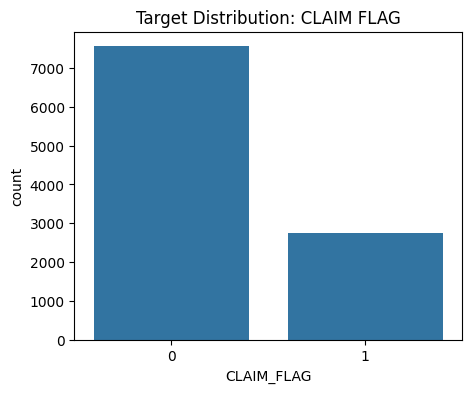

In [66]:
plt.figure(figsize=(5,4))
sns.countplot(x="CLAIM_FLAG", data=df)
plt.title("Target Distribution: CLAIM FLAG")
plt.show()

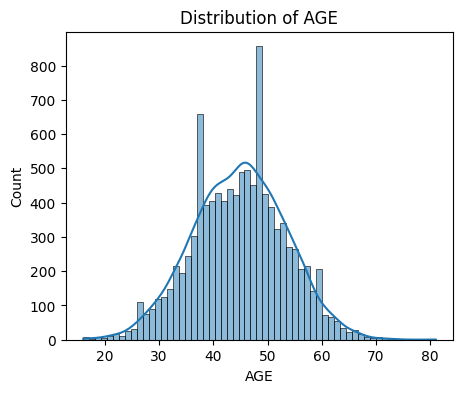

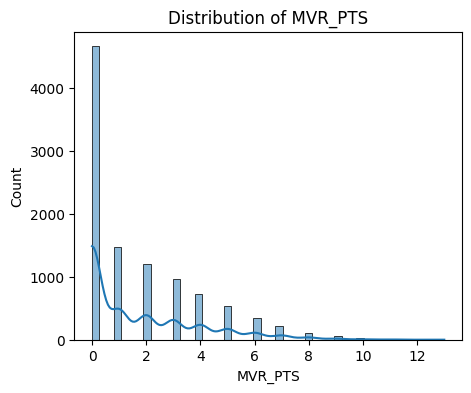

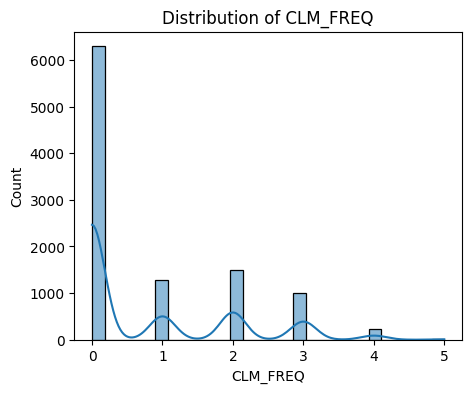

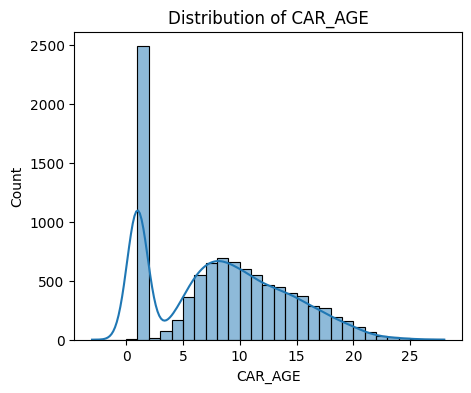

In [67]:
for col in ["AGE", "MVR_PTS", "CLM_FREQ", "CAR_AGE"]:
    if col in df.columns:
        plt.figure(figsize=(5,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

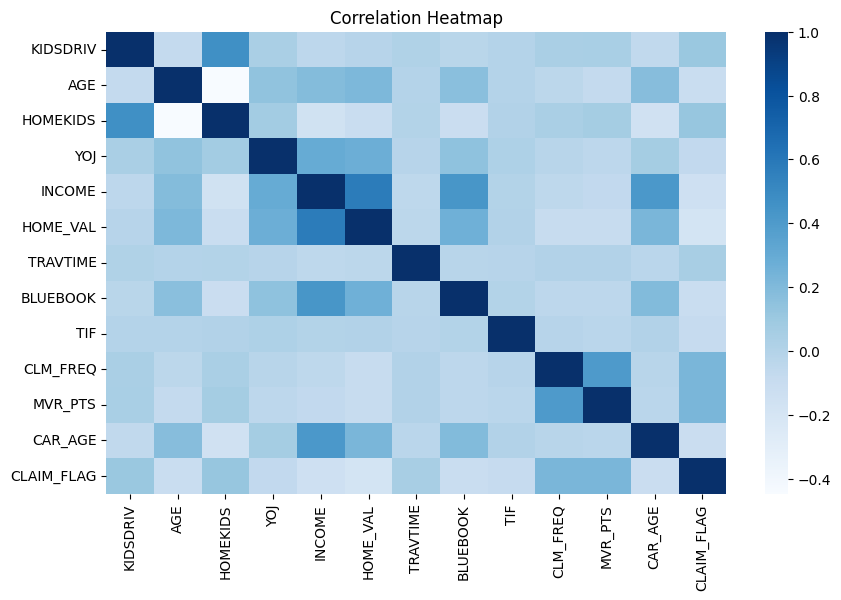

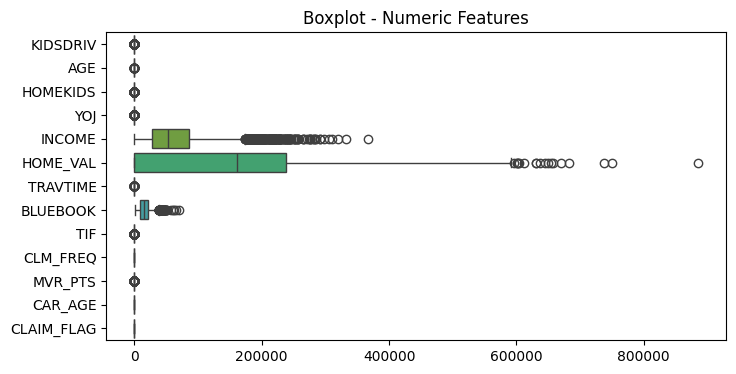

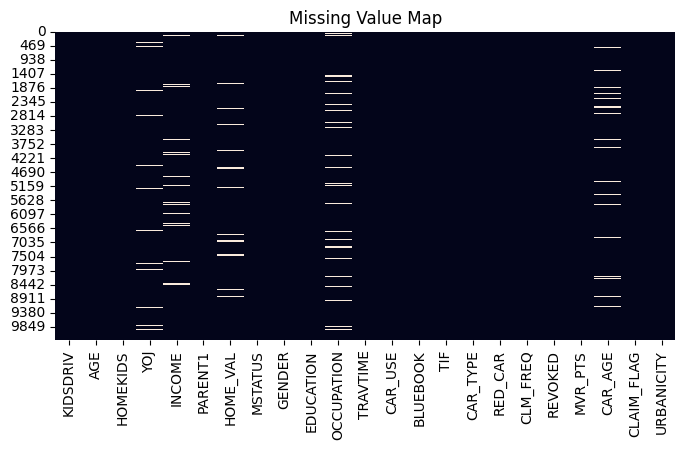

In [68]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplot - Numeric Features")
plt.show()

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Map")
plt.show()

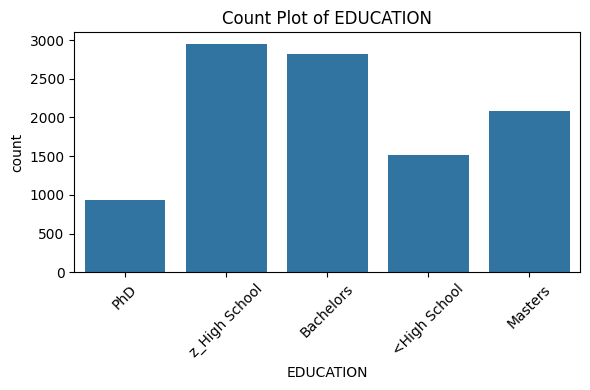

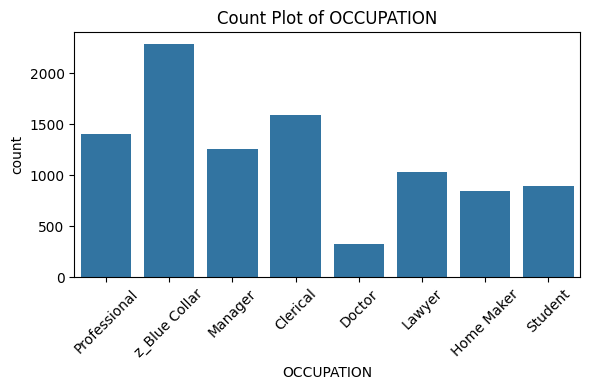

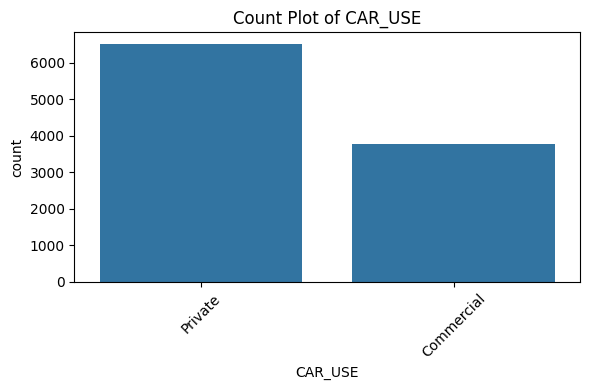

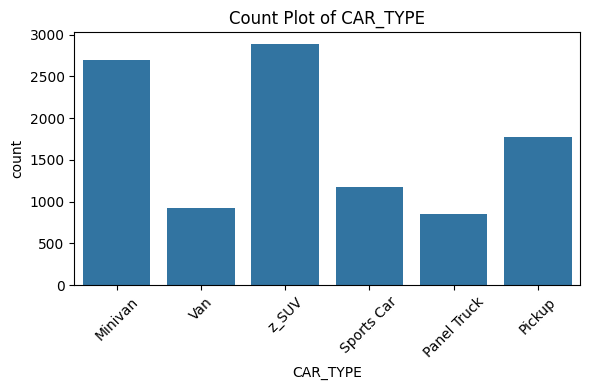

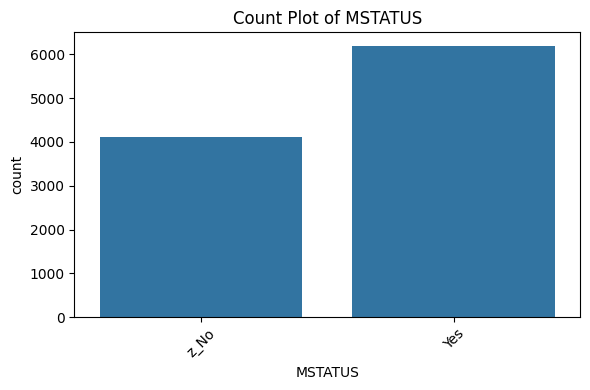

In [69]:
categorical_to_plot = ["EDUCATION", "OCCUPATION", "CAR_USE", "CAR_TYPE", "MSTATUS"]

for col in categorical_to_plot:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, data=df)
        plt.title(f"Count Plot of {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

5. Train/Test

In [70]:
target = "CLAIM_FLAG"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((8241, 22), (2061, 22))

6. Preprocessing

In [71]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

numeric_features, categorical_features

(['KIDSDRIV',
  'AGE',
  'HOMEKIDS',
  'YOJ',
  'INCOME',
  'HOME_VAL',
  'TRAVTIME',
  'BLUEBOOK',
  'TIF',
  'CLM_FREQ',
  'MVR_PTS',
  'CAR_AGE'],
 ['PARENT1',
  'MSTATUS',
  'GENDER',
  'EDUCATION',
  'OCCUPATION',
  'CAR_USE',
  'CAR_TYPE',
  'RED_CAR',
  'REVOKED',
  'URBANICITY'])

In [72]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

7. Model Evaluation

In [73]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n=== {name} ===")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC: {auc:.4f}")

        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve - {name}")
        plt.show()

8. Model 1 - Logistic Regression (with SMOTE)


=== Logistic Regression ===
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1512
           1       0.49      0.74      0.59       549

    accuracy                           0.72      2061
   macro avg       0.69      0.73      0.69      2061
weighted avg       0.78      0.72      0.74      2061

Confusion Matrix:
 [[1080  432]
 [ 140  409]]
ROC-AUC: 0.8100


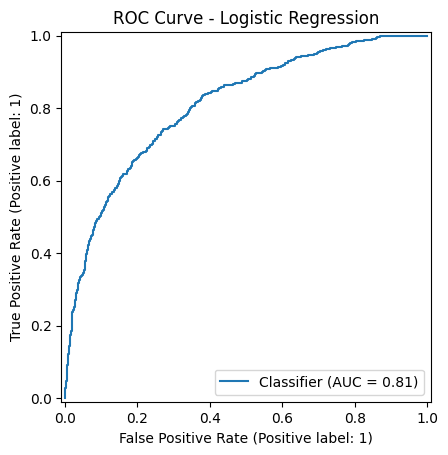

In [74]:
log_reg_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000))
])

log_reg_clf.fit(X_train, y_train)

evaluate_model("Logistic Regression", log_reg_clf, X_test, y_test)

9. Model 2 - Random Forest


=== Random Forest ===
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1512
           1       0.62      0.50      0.56       549

    accuracy                           0.79      2061
   macro avg       0.73      0.70      0.71      2061
weighted avg       0.77      0.79      0.78      2061

Confusion Matrix:
 [[1343  169]
 [ 273  276]]
ROC-AUC: 0.8146


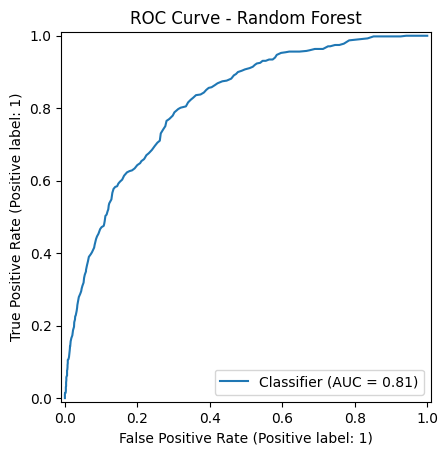

In [75]:
rf_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)

evaluate_model("Random Forest", rf_clf, X_test, y_test)

10. Model 3 - Gradient Boosting


=== Gradient Boosting ===
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1512
           1       0.63      0.57      0.60       549

    accuracy                           0.80      2061
   macro avg       0.74      0.73      0.73      2061
weighted avg       0.79      0.80      0.79      2061

Confusion Matrix:
 [[1331  181]
 [ 236  313]]
ROC-AUC: 0.8269


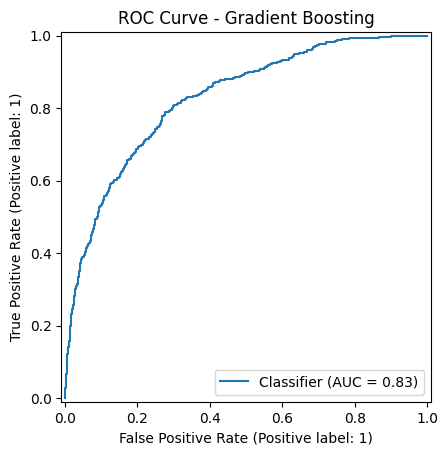

In [76]:
gb_clf = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    ))
])

gb_clf.fit(X_train, y_train)

evaluate_model("Gradient Boosting", gb_clf, X_test, y_test)

In [77]:
param_grid_gb = {
    "clf__n_estimators": [200, 300],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 4]
}

gb_grid = GridSearchCV(
    gb_clf,
    param_grid_gb,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters: ", gb_grid.best_params_)
print("Best CV AUC: ", gb_grid.best_score_)

Best parameters:  {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Best CV AUC:  0.8131788736161396


11. Feature Importance (Gradient Boosting)

In [78]:
# Get feature names from the preprocessor
ohe = gb_clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

num_feature_names = numeric_features
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

# Extract feature importance from Gradient Boosting
gb_model = gb_clf.named_steps["clf"]
importances = gb_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
9,CLM_FREQ,0.177235
10,MVR_PTS,0.093340
44,URBANICITY_z_Highly Rural/ Rural,0.073551
33,CAR_TYPE_Minivan,0.071034
43,URBANICITY_Highly Urban/ Urban,0.065378
8,TIF,0.056858
27,OCCUPATION_Manager,0.056018
22,EDUCATION_z_High School,0.055374
5,HOME_VAL,0.037878
42,REVOKED_Yes,0.026813


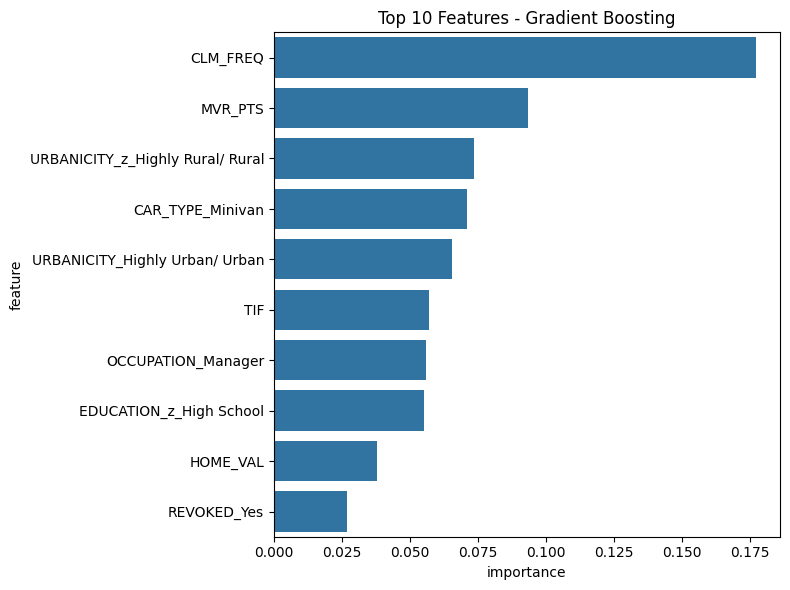

In [79]:
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature")
plt.title("Top 10 Features - Gradient Boosting")
plt.tight_layout()
plt.show()